# Figure 2

## Imports

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import json
import pickle
import os
import importlib
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy import stats as scipy_stats

import analysis_functions as afuncs
import cesm2_lens_utils
importlib.reload(afuncs)
importlib.reload(cesm2_lens_utils)

<module 'cesm2_lens_utils' from '/glade/u/home/cassiacai/measures/cesm2_lens_utils.py'>

## Load data

In [4]:
base_paths = {
    'linear':    '/glade/work/cmendiola/data_conv_lin_trend',
    'quadratic': '/glade/work/cmendiola/data_quad_trend',
    'ensmean':   '/glade/work/cmendiola/data_ens_mean',
    'noseas':    '/glade/work/cmendiola/data_rm_seasonalcycle_mean',
}
RADIUS_INDEX_FOR_2DEG = 1  # index 1 = 2-degree structuring element, confirmed across all four methods
ssta_varnames = {
    'linear': '__xarray_dataarray_variable__',
    'quadratic': '__xarray_dataarray_variable__',
    'ensmean': 'SST',
    'noseas': '__xarray_dataarray_variable__',
}


# ============================================================
# Load all four methods: labels + SSTa (radius-corrected, time-restricted)
# ============================================================
da_mhwobj_labels_by_method = {}
ssta_notrend_by_method = {}
for method, base_path in base_paths.items():
    mhwobj_paths = [f'{base_path}/ens_{i}_mhwobj.nc' for i in range(100)]
    ssta_paths = [f'{base_path}/ens_{i}_ssta.nc' for i in range(100)]
    da_mhwobj = xr.open_mfdataset(mhwobj_paths, combine='nested', concat_dim='ensemble_member')
    da_mhwobj_labels_by_method[method] = (
        da_mhwobj.labels.sel(radius=RADIUS_INDEX_FOR_2DEG)
        .sel(time=slice('1979-01', '2020-12'))
        .compute()
    )
    ssta_notrend_by_method[method] = xr.open_mfdataset(ssta_paths, combine='nested', concat_dim='ensemble_member').compute()

print("All four methods loaded.")
print({m: da_mhwobj_labels_by_method[m].sizes for m in base_paths})

All four methods loaded.
{'linear': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'quadratic': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'ensmean': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'noseas': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81})}


/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/dask/_task_spec.py:758: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  return self.func(*new_argspec, **kwargs)
/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/dask/_task_spec.py:758: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of 

In [5]:
# Blob-analog IDs (50% overlap threshold)
thresholds = np.arange(0.1, 0.81, 0.1)
OVERLAP_THRESHOLD_INDEX = 4  # 0.5 (50%)

blob_analog_ids = {}
object_id_json_paths = {
    'linear':    'object_id_ls_greenmask_linear_corrected.json',
    'quadratic': 'object_id_ls_greenmask_quadratic_corrected.json',
    'ensmean':   'object_id_ls_greenmask_ensmean_corrected.json',
    'noseas':    'object_id_ls_greenmask_noseas_corrected.json',
}
for method, path in object_id_json_paths.items():
    with open(path, 'r') as f:
        all_thresholds = json.load(f)
    blob_analog_ids[method] = all_thresholds[OVERLAP_THRESHOLD_INDEX]

print({m: sum(len(v) for v in blob_analog_ids[m]) for m in blob_analog_ids})
print("VERIFY: linear should be ~331")

{'linear': 331, 'quadratic': 327, 'ensmean': 312, 'noseas': 343}
VERIFY: linear should be ~331


In [ ]:
# Cell area weighting (CESM2-LENS grid)
R = 6371.0
grid_ref = da_mhwobj_labels_by_method['linear']
dlat = np.deg2rad(np.mean(np.diff(grid_ref.lat.values)))
dlon = np.deg2rad(np.mean(np.diff(grid_ref.lon.values)))
cell_area = (R**2) * dlat * dlon * np.cos(np.deg2rad(grid_ref.lat))
cell_area_da = xr.DataArray(cell_area.values, coords={'lat': grid_ref.lat}, dims='lat')

check_val = float(cell_area_da.sel(lat=grid_ref.lat.values[len(grid_ref.lat)//2]))
print(f"Equatorial gridcell area check: {check_val:.1f} km² -- VERIFY: should be ~11881.4")

In [ ]:
# FOSI Blob reference event
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels
object_id = 94.0
blob_times = fosi_blobs.time.where((fosi_blobs == object_id).any(dim=('lat', 'lon')), drop=True)
print(f"n_months in blob_times: {len(blob_times)} -- VERIFY: should be 20")

regridded_ssta_no_trend_NEP = xr.open_dataset('/glade/derecho/scratch/cassiacai/regridded_ssta_no_trend_NEP.nc')
regridded_ssta_no_trend_NEP_da = regridded_ssta_no_trend_NEP['__xarray_dataarray_variable__']
check_max = float(regridded_ssta_no_trend_NEP_da.sel(time='2015-07').max().values)
print(f"FOSI July 2015 max SSTa: {check_max:.2f} -- VERIFY: should be ~2.34")

In [ ]:
# MLD: canonical footprint mask setup (POP grid)
lat_slice = slice(204, 367)
lon_slice = slice(190, 280)
mean_image_pop_files = [f'/glade/derecho/scratch/cassiacai/mean_image_{i}_POP.nc' for i in range(1, 8)]
mean_images_pop = [xr.open_dataset(file) for file in mean_image_pop_files]
masks_pop = [xr.where(image.__xarray_dataarray_variable__ > 0.1, 1, 0) for image in mean_images_pop]
NEPac_MHW_renamed_latlon = masks_pop[2].isel(nlat=lat_slice, nlon=lon_slice).rename({'nlat': 'nlat_t', 'nlon': 'nlon_t'})

## Functions

In [ ]:
# MLD per analog
def process_one_member_mld(member_id, labels_full, analog_ids_for_member, all_analog_mld, NEPac_mask):
    if not analog_ids_for_member:
        print(f"Member {member_id}: no analogs, skipping")
        return all_analog_mld

    member_labels = labels_full.isel(ensemble_member=member_id)
    ds_hist, ds_fut = afuncs.get_ds_var(
        '/glade/campaign/cgd/cesm/CESM2-LE/ocn/proc/tseries/month_1/HMXL/', 'HMXL', 'ocn', member_id
    )
    hmxl_hist_cropped = ds_hist.HMXL.isel(nlat=lat_slice, nlon=lon_slice)
    hmxl_fut_cropped = ds_fut.HMXL.isel(nlat=lat_slice, nlon=lon_slice)
    hmxl_combined = xr.concat([hmxl_hist_cropped, hmxl_fut_cropped], dim='time').sel(
        time=slice('1979-01-01', '2020-12-01')
    )
    hmxl_combined = hmxl_combined.rename({'nlat': 'nlat_t', 'nlon': 'nlon_t'}).assign_coords(
        nlat_t=NEPac_mask.nlat_t, nlon_t=NEPac_mask.nlon_t
    ) / 100.0

    for analog_id in analog_ids_for_member:
        key = (member_id, analog_id)
        if key in all_analog_mld:
            continue
        times_present = member_labels.time.where((member_labels == analog_id).any(dim=('lat', 'lon')), drop=True)
        if len(times_present) == 0:
            continue
        hmxl_masked = (hmxl_combined.sel(time=times_present) * NEPac_mask).compute()
        hmxl_masked = hmxl_masked.where(hmxl_masked != 0)
        all_analog_mld[key] = {
            'mld_mean': float(hmxl_masked.mean()),
            'mld_max': float(hmxl_masked.max()),
            'mld_p90': float(hmxl_masked.quantile(0.9)),
        }
    print(f"Member {member_id}: done ({len(analog_ids_for_member)} analogs)")
    return all_analog_mld

In [ ]:
def compute_analog_characteristics(labels_da, analog_id, ssta_da, mld_da, cell_area_da):
    mask = (labels_da == analog_id)
    times_present = labels_da.time.where(mask.any(dim=('lat', 'lon')), drop=True)
    if len(times_present) == 0:
        return None
    mask_trimmed = mask.sel(time=times_present)
    ssta_masked = ssta_da.sel(time=times_present).where(mask_trimmed)
    extent_ts = (mask_trimmed.astype(int) * cell_area_da).sum(dim=('lat', 'lon'))
    result = {
        'duration': len(times_present),
        'intensity_mean': float(ssta_masked.mean()),
        'intensity_max': float(ssta_masked.max()),
        'extent_mean': float(extent_ts.mean()),
        'extent_max': float(extent_ts.max()),
        'extent_cumulative': float(extent_ts.sum()),
    }
    if mld_da is not None:
        mld_masked = mld_da.sel(time=times_present).where(mask_trimmed)
        result['mld_mean'] = float(mld_masked.mean())
        result['mld_max'] = float(mld_masked.max())
    return result

In [ ]:
def unflatten_climate_stats(flat_dict):
    unflattened = {}
    for flat_key, v in flat_dict.items():
        parts = flat_key.split('_')
        method = parts[0]
        member_id = int(parts[1])
        analog_id = float(parts[2])
        unflattened[(method, member_id, analog_id)] = v
    return unflattened

## Mixed layer depth and other metrics

In [ ]:
results_path = 'analog_mld_results.pkl'
if os.path.exists(results_path):
    with open(results_path, 'rb') as f:
        all_analog_mld = pickle.load(f)
    print(f"Resuming - {len(all_analog_mld)} analogs already processed")
else:
    all_analog_mld = {}

labels_full = da_mhwobj_labels_by_method['linear']
for member_id in range(100):
    all_analog_mld = process_one_member_mld(
        member_id, labels_full, blob_analog_ids['linear'][member_id], all_analog_mld, NEPac_MHW_renamed_latlon
    )
    with open(results_path, 'wb') as f:
        pickle.dump(all_analog_mld, f)

print(f"Done. Total analogs with MLD: {len(all_analog_mld)} -- VERIFY: should be ~331")

In [ ]:
all_analog_characteristics = {}
ssta_full = ssta_notrend_by_method['linear'][ssta_varnames['linear']]
for member_id in range(100):
    member_labels = labels_full.isel(ensemble_member=member_id)
    member_ssta = ssta_full.isel(ensemble_member=member_id)
    for analog_id in blob_analog_ids['linear'][member_id]:
        result = compute_analog_characteristics(member_labels, analog_id, member_ssta, None, cell_area_da)
        if result:
            all_analog_characteristics[(member_id, analog_id)] = result

print(f"Total analogs characterized: {len(all_analog_characteristics)} -- VERIFY: should be ~331")

# Merge in MLD stats computed separately above
for key, mld_stats in all_analog_mld.items():
    if key in all_analog_characteristics:
        all_analog_characteristics[key].update(mld_stats)

n_with_mld = sum(1 for v in all_analog_characteristics.values() if 'mld_mean' in v)
print(f"Analogs with full characteristics (incl. MLD): {n_with_mld} / {len(all_analog_characteristics)}")

In [ ]:
# FOSI Blob's characteristics
# ============================================================
dlat_fosi = np.deg2rad(np.mean(np.diff(fosi_blobs.lat.values)))
dlon_fosi = np.deg2rad(np.mean(np.diff(fosi_blobs.lon.values)))
cell_area_fosi = (R**2) * dlat_fosi * dlon_fosi * np.cos(np.deg2rad(fosi_blobs.lat))
cell_area_da_fosi = xr.DataArray(cell_area_fosi.values, coords={'lat': fosi_blobs.lat}, dims='lat')

check_val_fosi = float(cell_area_da_fosi.sel(lat=fosi_blobs.lat.values[len(fosi_blobs.lat)//2]))
print(f"FOSI equatorial check: {check_val_fosi:.1f} km² -- VERIFY: should be ~11881.4")

blob_fosi_characteristics = compute_analog_characteristics(
    fosi_blobs, object_id, regridded_ssta_no_trend_NEP_da, None, cell_area_da_fosi
)
# MLD values already computed/confirmed separately (hardcoded from previous)
blob_fosi_characteristics['mld_mean'] = 57.8
blob_fosi_characteristics['mld_max'] = 225.7
blob_fosi_characteristics['mld_p90'] = 103.8

print(blob_fosi_characteristics)
print("VERIFY: duration=20, intensity_max~2.34, extent_max~24.3e6 km², mld_mean=57.8, mld_max=225.7")

In [ ]:
save_bundle = {
    'all_analog_characteristics': all_analog_characteristics,
    'blob_fosi_characteristics': blob_fosi_characteristics,
}
with open('/glade/derecho/scratch/cassiacai/section_3_2_analog_data.pkl', 'wb') as f:
    pickle.dump(save_bundle, f)

print("Saved section_3_2_analog_data.pkl")
print(f"  - {len(all_analog_characteristics)} analogs with physical characteristics")

## Creating section_3_2_analog_data

In [7]:
# Load analog characteristics and FOSI Blob characteristics
with open('/glade/derecho/scratch/cassiacai/section_3_2_analog_data.pkl', 'rb') as f:
    save_bundle = pickle.load(f)

all_analog_characteristics = save_bundle['all_analog_characteristics']
blob_fosi_characteristics = save_bundle['blob_fosi_characteristics']

print(f"Loaded {len(all_analog_characteristics)} analog characteristics -- VERIFY: 331")
print(f"blob_fosi_characteristics keys: {list(blob_fosi_characteristics.keys())}")

# Sanity check: confirm the fields the figure needs are present
required_fields = ['extent_max', 'duration', 'mld_max', 'mld_mean', 'intensity_max', 'intensity_mean']
sample_key = list(all_analog_characteristics.keys())[0]
print(f"\nSample analog ({sample_key}) fields available: {list(all_analog_characteristics[sample_key].keys())}")
missing = [f for f in required_fields if f not in blob_fosi_characteristics]
if missing:
    print(f"WARNING: blob_fosi_characteristics missing fields needed for this figure: {missing}")
else:
    print("All required fields present in blob_fosi_characteristics.")

Loaded 331 analog characteristics -- VERIFY: 331
blob_fosi_characteristics keys: ['duration', 'intensity_mean', 'intensity_max', 'extent_mean', 'extent_max', 'extent_cumulative', 'mld_mean', 'mld_max', 'mld_p90']

Sample analog ((0, 28.0)) fields available: ['duration', 'intensity_mean', 'intensity_max', 'extent_mean', 'extent_max', 'extent_cumulative', 'mld_mean', 'mld_max', 'mld_p90']
All required fields present in blob_fosi_characteristics.


In [8]:
# Reload PDO/Niño3.4 climate stats and merge into all_analog_characteristics
with open('/glade/derecho/scratch/cassiacai/climate_stats_canonical.json', 'r') as f:
    climate_stats_canonical_flat = json.load(f)
climate_stats_canonical = unflatten_climate_stats(climate_stats_canonical_flat)

print(f"Loaded {len(climate_stats_canonical)} entries (all methods combined)")

# Filter to linear method only, matching all_analog_characteristics' key structure (member_id, analog_id)
climate_stats_linear = {
    (member_id, analog_id): v
    for (method, member_id, analog_id), v in climate_stats_canonical.items()
    if method == 'linear'
}
print(f"Linear-only: {len(climate_stats_linear)} analogs -- VERIFY: 331")

sample_key = list(climate_stats_linear.keys())[0]
print(f"Sample climate stats fields: {list(climate_stats_linear[sample_key].keys())}")

# Merge into all_analog_characteristics
n_merged = 0
for key in all_analog_characteristics:
    if key in climate_stats_linear:
        all_analog_characteristics[key].update(climate_stats_linear[key])
        n_merged += 1

print(f"Merged climate stats into {n_merged} / {len(all_analog_characteristics)} analog characteristics entries")

Loaded 1313 entries (all methods combined)
Linear-only: 331 analogs -- VERIFY: 331
Sample climate stats fields: ['nino34_mean', 'nino34_max', 'pdo_mean', 'pdo_max']
Merged climate stats into 331 / 331 analog characteristics entries


In [9]:
blob_fosi_characteristics.update({
    'nino34_mean': 1.1281,
    'nino34_max': 3.0775,
    'pdo_mean': 1.0245,
    'pdo_max': 1.8463,
})
print("blob_fosi_characteristics updated with PDO/Niño3.4:", blob_fosi_characteristics)

blob_fosi_characteristics updated with PDO/Niño3.4: {'duration': 20, 'intensity_mean': 1.0101917806077365, 'intensity_max': 2.3448744454154564, 'extent_mean': 12854675.1150951, 'extent_max': 24261030.79022178, 'extent_cumulative': 257093502.301902, 'mld_mean': 57.8, 'mld_max': 225.7, 'mld_p90': 103.8, 'nino34_mean': 1.1281, 'nino34_max': 3.0775, 'pdo_mean': 1.0245, 'pdo_max': 1.8463}


## Visualization

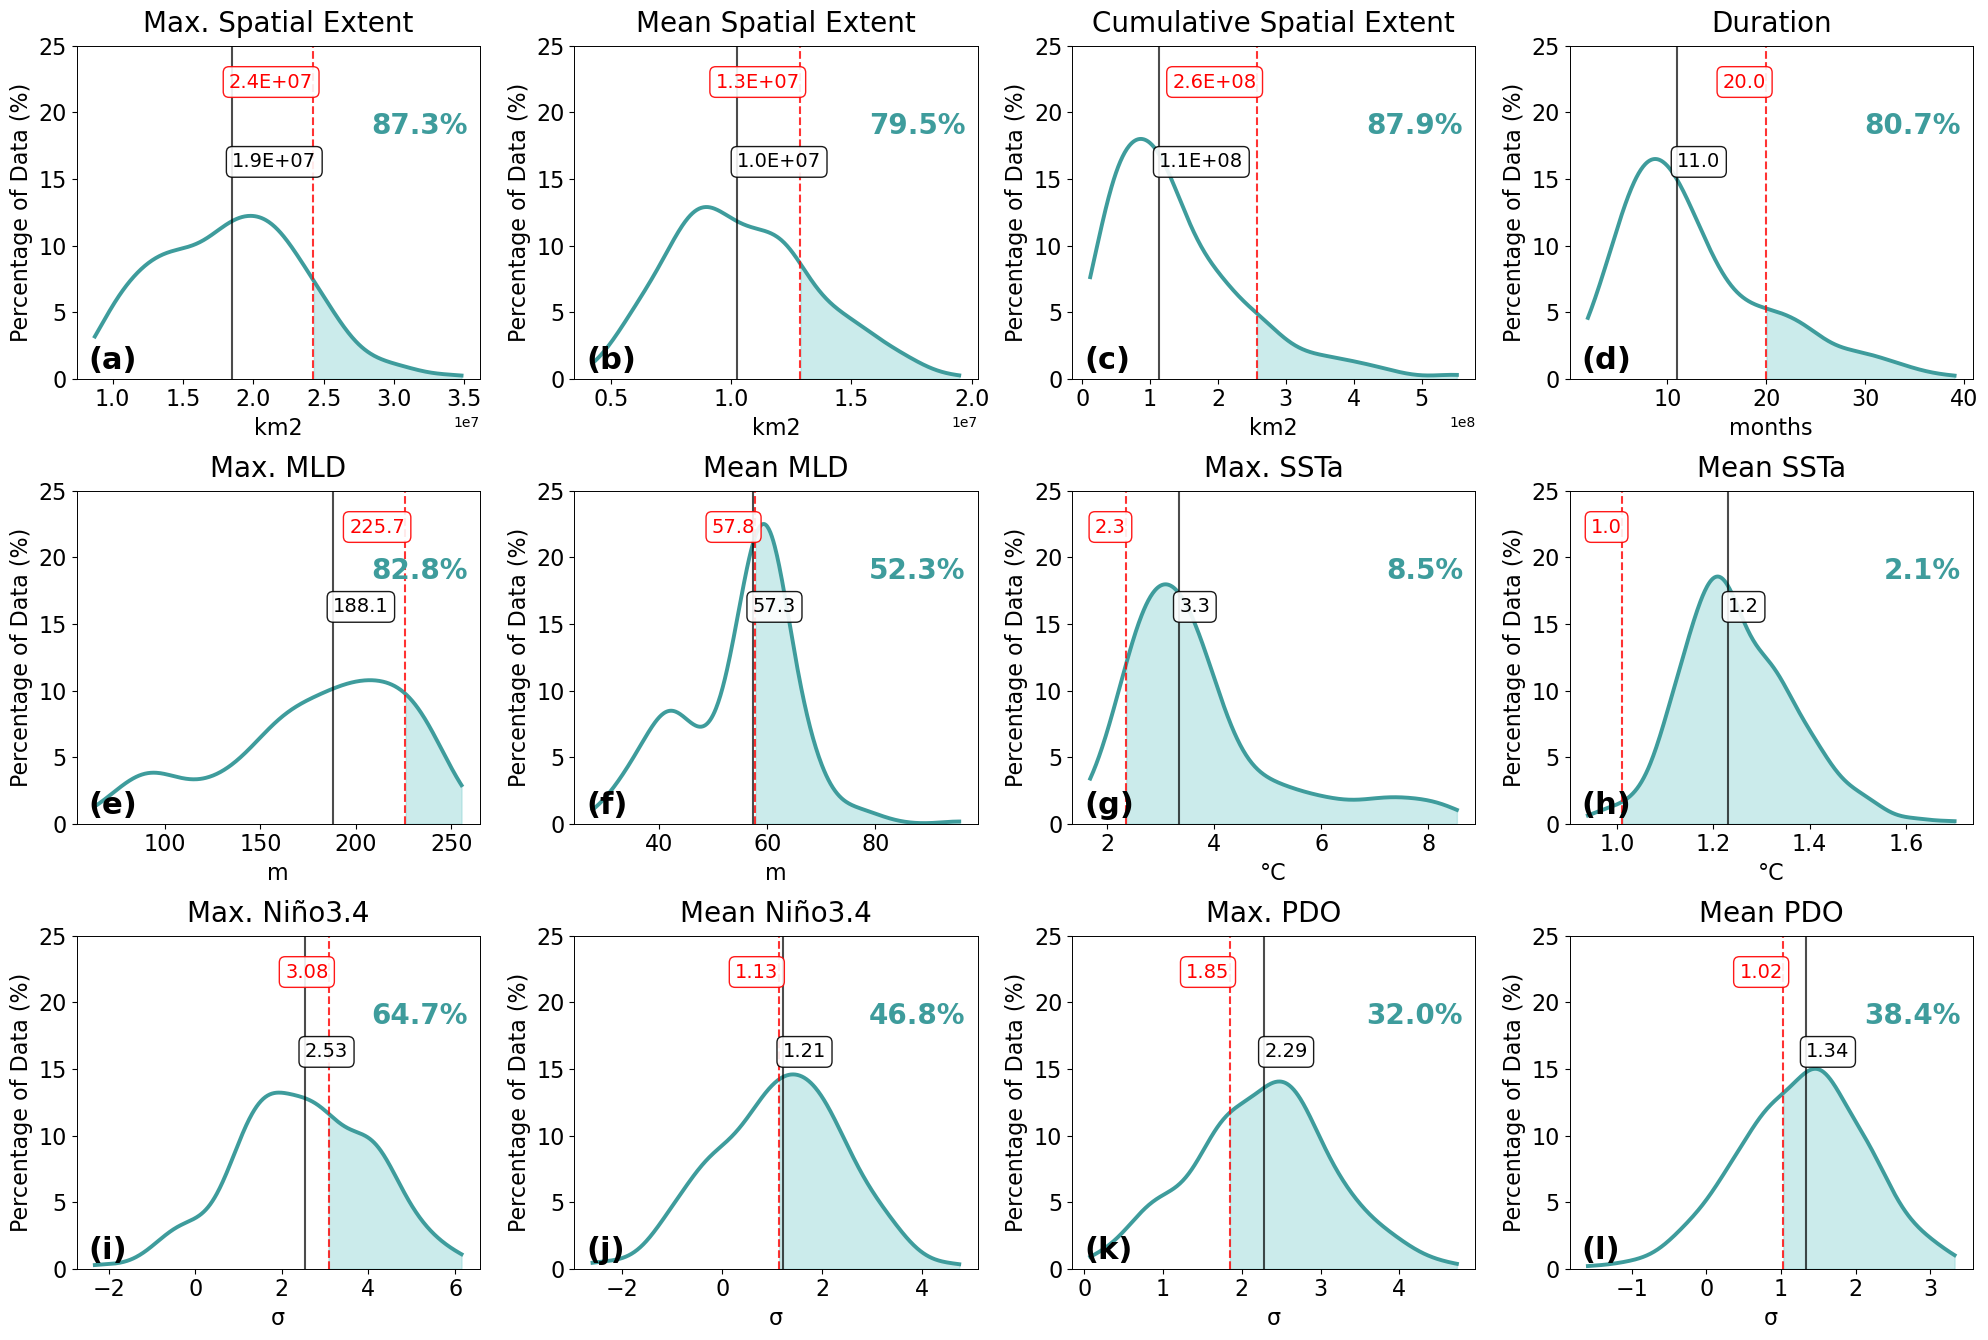

In [10]:
panel_specs = [
    ('extent_max', 'Max. Spatial Extent', 'km2', '{:.1E}'),
    ('extent_mean', 'Mean Spatial Extent', 'km2', '{:.1E}'),
    ('extent_cumulative', 'Cumulative Spatial Extent', 'km2', '{:.1E}'),
    ('duration', 'Duration', 'months', '{:.1f}'),
    ('mld_max', 'Max. MLD', 'm', '{:.1f}'),
    ('mld_mean', 'Mean MLD', 'm', '{:.1f}'),
    ('intensity_max', 'Max. SSTa', '°C', '{:.1f}'),
    ('intensity_mean', 'Mean SSTa', '°C', '{:.1f}'),
    ('nino34_max', 'Max. Niño3.4', 'σ', '{:.2f}'),
    ('nino34_mean', 'Mean Niño3.4', 'σ', '{:.2f}'),
    ('pdo_max', 'Max. PDO', 'σ', '{:.2f}'),
    ('pdo_mean', 'Mean PDO', 'σ', '{:.2f}'),
]

fig, axes = plt.subplots(3, 4, figsize=(20, 13.5))
axes = axes.flatten()
letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l']

for ax, (char, title, xlabel, fmt), letter in zip(axes, panel_specs, letters):
    values = np.array([c[char] for c in all_analog_characteristics.values() if char in c])
    counts, bin_edges = np.histogram(values, bins=15)
    bin_width = bin_edges[1] - bin_edges[0]
    kde = gaussian_kde(values)
    x = np.linspace(values.min(), values.max(), 500)
    y_pct = kde(x) * bin_width * 100
    ax.plot(x, y_pct, color='#3E9C9C', linewidth=2.8)
    median_val = np.median(values)
    fosi_val = blob_fosi_characteristics[char]
    mask = x >= fosi_val
    ax.fill_between(x[mask], y_pct[mask], color='#7FCFCF', alpha=0.4)
    ax.axvline(fosi_val, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.axvline(median_val, color='k', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.text(fosi_val, 23, fmt.format(fosi_val), ha='right', va='top', fontsize=14, color='red',
            bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.9))
    ax.text(median_val, 17, fmt.format(median_val), ha='left', va='top', fontsize=14, color='k',
            bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.9))
    pct = 100 * (1 - np.mean(values >= fosi_val))
    ax.text(0.97, 0.8, f"{pct:.1f}%", transform=ax.transAxes, ha='right', va='top',
            fontsize=20, color='#3E9C9C', fontweight='bold')
    ax.text(0.03, 0.03, f"({letter})", transform=ax.transAxes, fontsize=22, fontweight='bold')
    ax.set_title(title, fontsize=20, pad=10)
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel('Percentage of Data (%)', fontsize=16)
    ax.set_ylim(0, 25)
    ax.tick_params(labelsize=16)
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('k')
        spine.set_linewidth(0.7)

plt.tight_layout()
plt.show()

In [13]:
for char, blob_val in [('nino34_mean', blob_fosi_characteristics['nino34_mean']),
                        ('nino34_max', blob_fosi_characteristics['nino34_max']),
                        ('pdo_mean', blob_fosi_characteristics['pdo_mean']),
                        ('pdo_max', blob_fosi_characteristics['pdo_max'])]:
    values = np.array([c[char] for c in all_analog_characteristics.values() if char in c])
    pct_below = 100 * np.mean(values < blob_val)
    pct_at_or_above = 100 * np.mean(values >= blob_val)
    print(f"{char}: Blob={blob_val:.3f} | % below={pct_below:.1f} | % at-or-above={pct_at_or_above:.1f}")

nino34_mean: Blob=1.128 | % below=46.8 | % at-or-above=53.2
nino34_max: Blob=3.078 | % below=64.7 | % at-or-above=35.3
pdo_mean: Blob=1.024 | % below=38.4 | % at-or-above=61.6
pdo_max: Blob=1.846 | % below=32.0 | % at-or-above=68.0


In [14]:
# Correlations: mean Niño3.4 vs. physical severity metrics
extent_vals = np.array([c['extent_max'] for c in all_analog_characteristics.values() if 'nino34_mean' in c])
duration_vals = np.array([c['duration'] for c in all_analog_characteristics.values() if 'nino34_mean' in c])
intensity_vals = np.array([c['intensity_max'] for c in all_analog_characteristics.values() if 'nino34_mean' in c])
nino34_vals = np.array([c['nino34_mean'] for c in all_analog_characteristics.values() if 'nino34_mean' in c])

r_extent, p_extent = scipy_stats.pearsonr(nino34_vals, extent_vals)
r_duration, p_duration = scipy_stats.pearsonr(nino34_vals, duration_vals)
r_intensity, p_intensity = scipy_stats.pearsonr(nino34_vals, intensity_vals)

print(f"n = {len(nino34_vals)}")
print(f"Niño3.4 vs. extent: r={r_extent:.2f}, p={p_extent:.4f}")
print(f"Niño3.4 vs. duration: r={r_duration:.2f}, p={p_duration:.4f}")
print(f"Niño3.4 vs. intensity: r={r_intensity:.2f}, p={p_intensity:.4f}")

n = 331
Niño3.4 vs. extent: r=0.33, p=0.0000
Niño3.4 vs. duration: r=-0.01, p=0.8449
Niño3.4 vs. intensity: r=-0.04, p=0.5051
